# A selective state space model, written out step by step

**Docker image**: `ml4t-gpu`

`06_tsmixer` related the days in a window with one dense $T \times T$ map, and
`04_transformers` related every day to every other through attention. Both cost
$T^2$, and both gave up the idea that a sequence can be walked once while carrying a
state - the idea `01_core_architectures` measured the price of, because a state
updated one day at a time cannot be computed in parallel across days.

A **state space model** takes the recurrence back and changes what is carried. Its
state has a fixed size and each step does a bounded amount of work, so one sweep is
$O(T)$ - which an LSTM also manages. What the *linear* update adds is that the steps
compose: the recurrence is affine, and each step's coefficients can be computed
without knowing the previous state, so the sweep is an associative scan that runs in
parallel across the sequence instead of a loop that waits for its own output. **Mamba** (Gu and Dao, 2023) adds what makes that
competitive: the matrices reading the input into the state and the state into the
output, and the step size itself, are computed *from the input at that step*. The
model decides what to keep as it goes, which a fixed-parameter SSM cannot.

**Learning objectives**:
- Read the discrete recurrence off the code and say which of its terms are constant
  across the sequence and which are functions of the current input.
- Say what "selective" buys over a fixed-parameter SSM, in terms of what the state
  can be made to forget.
- Name the simplifications this implementation makes against the paper, and find
  each one in the code rather than taking the list on trust.
- Score the result against a penalised linear map on the same window, and read the
  comparison for what a capped training budget allows it to say.

**Book Reference**: Chapter 13, Section 13.6 (Alternative architectures and foundation models)

**What this implementation is.** A pedagogical selective SSM in pure PyTorch,
written so the recurrence is readable rather than fast. It carries Mamba's defining
mechanism - $B_t$, $C_t$ and $\Delta_t$ computed from the input at step $t$ - and
departs from the reference `mamba_ssm` package in four ways you can find in the code
below:

- The scan is a Python `for` loop over timesteps, not a parallel associative scan in
  a CUDA kernel. The $O(T)$ work is the same; the constant is roughly a hundred times
  worse, which is why the sample is capped further down.
- $\Delta_t$ is one scalar per timestep, shared across all channels: `x_proj` emits
  `d_state * 2 + 1` values and the last one is the step size. Mamba gives each channel
  its own.
- The input discretization is approximated as $\bar B_t \approx \Delta_t B_t$ rather
  than the full zero-order-hold expression.
- There is no depthwise causal convolution before the SSM branch, which the paper's
  block includes.

Read it as a sketch of the selective-state-space idea, not as a drop-in replacement.

**Prerequisites**: ETF features (`case_studies/etfs/`)

In [1]:
"""Simplified Selective State Space Model - pedagogical Mamba implementation for return prediction."""

import os

os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dl_sequences import create_sequences_multi_asset, load_dl_dataset, train_model
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from plotly.subplots import make_subplots
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from utils.reproducibility import set_global_seeds
from utils.style import (  # COLORS activates the ml4t Plotly template on import
    COLORS,
    show_plotly_with_alt,
)

In [2]:
SEED = 42
LOOKBACK = 60
D_MODEL = 32
D_STATE = 16
N_LAYERS = 2
DROPOUT = 0.1
EPOCHS = 10
BATCH_SIZE = 128
LR = 1e-3
MAX_TRAIN_SAMPLES = 50_000
MAX_VAL_SAMPLES = 15_000
MAX_TEST_SAMPLES = 15_000
INFER_BATCH_SIZE = 1_024
LABEL_HORIZON = 21

In [3]:

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

set_global_seeds(SEED)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

Device: cuda


## Data Loading

We use eight fixed momentum horizons from the ETF case-study pipeline.

In [4]:
mds = load_dl_dataset("etfs")

FEATURE_COLS = [
    "ret_5d",
    "ret_10d",
    "ret_21d",
    "ret_42d",
    "ret_63d",
    "ret_126d",
    "ret_189d",
    "ret_252d",
]
TARGET_COL = mds.label_col

missing_features = sorted(set(FEATURE_COLS) - set(mds.feature_names))
if missing_features:
    raise ValueError(f"Missing required ETF momentum features: {missing_features}")

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Target: {TARGET_COL}")

Loaded etfs: 402,526 rows, 71 features, 99 entities, label=fwd_ret_21d
Features (8): ['ret_5d', 'ret_10d', 'ret_21d', 'ret_42d', 'ret_63d', 'ret_126d', 'ret_189d', 'ret_252d']
Target: fwd_ret_21d


## Sequence Creation and Temporal Split

In [5]:
df = mds.dataset.drop_nulls(subset=FEATURE_COLS + [TARGET_COL])
print(f"Rows after dropping nulls: {len(df):,}")
per_date = df.group_by(mds.date_col).len().sort(mds.date_col)
print(
    f"{df[mds.date_col].min()} to {df[mds.date_col].max()}, "
    f"{df[mds.entity_cols[0]].n_unique()} funds; funds per date "
    f"{per_date['len'].min()} to {per_date['len'].max()}, median {per_date['len'].median():.0f}"
)
print(
    f"Label {TARGET_COL}: mean {df[TARGET_COL].mean():+.5f}, "
    f"standard deviation {df[TARGET_COL].std():.5f}"
)

X, y, timestamps, symbols = create_sequences_multi_asset(
    df,
    FEATURE_COLS,
    TARGET_COL,
    LOOKBACK,
    timestamp_col=mds.date_col,
    symbol_col=mds.entity_cols[0],
)
print(f"Sequences: {X.shape[0]:,}, shape: {X.shape}")

sequence_order = np.lexsort((symbols.astype(str), timestamps))
X = np.nan_to_num(X[sequence_order], nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
y = np.nan_to_num(y[sequence_order], nan=0.0).astype(np.float32)
timestamps = timestamps[sequence_order]
symbols = symbols[sequence_order]

Rows after dropping nulls: 402,446
2007-01-04 to 2025-12-01, 99 funds; funds per date 47 to 96, median 90
Label fwd_ret_21d: mean +0.00692, standard deviation 0.06028


Sequences: 396,506, shape: (396506, 60, 8)


### Splitting by date, with a gap for the label horizon

The split is by date, at fixed fractions of the trading days, and an example belongs
to the partition the date it carries falls in. The label is a `LABEL_HORIZON`-day
forward return, so an example dated within that many days of a boundary has an
outcome resolved by days on the far side; those examples are dropped. Input windows
may still reach back over a boundary, which is right - at decision time the model has
every past observation available.

In [6]:
unique_dates = np.sort(np.unique(timestamps))
train_boundary_idx = int(len(unique_dates) * 0.6)
val_boundary_idx = int(len(unique_dates) * 0.8)
train_end_date = unique_dates[train_boundary_idx]
val_end_date = unique_dates[val_boundary_idx]
train_label_cutoff = unique_dates[train_boundary_idx - LABEL_HORIZON]
val_label_cutoff = unique_dates[val_boundary_idx - LABEL_HORIZON]

train_mask = timestamps < train_label_cutoff
val_mask = (timestamps >= train_end_date) & (timestamps < val_label_cutoff)
test_mask = timestamps >= val_end_date

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]
test_dates, test_symbols = timestamps[test_mask], symbols[test_mask]

### Pedagogical subsampling

The pure-Python selective scan is roughly 100× slower than the production
CUDA kernel, so we cap each split at a few thousand sequences for tractable
wall-clock. Critically we subsample by **complete dates**, not row-count: a
raw `[-MAX_SAMPLES:]` slice would start mid-date and leave a partial
cross-section, which biases the per-date Spearman IC. We instead keep the
most recent dates whose total row count fits under the cap.

In [7]:
def _trim_by_complete_dates(X_arr, y_arr, ts_arr, sym_arr, max_samples):
    if len(X_arr) <= max_samples:
        return X_arr, y_arr, ts_arr, sym_arr
    unique_ts = np.sort(np.unique(ts_arr))[::-1]
    cumulative = 0
    keep_dates: list = []
    for ts in unique_ts:
        n = int((ts_arr == ts).sum())
        if cumulative + n > max_samples and keep_dates:
            break
        cumulative += n
        keep_dates.append(ts)
    keep_mask = np.isin(ts_arr, np.array(keep_dates))
    return X_arr[keep_mask], y_arr[keep_mask], ts_arr[keep_mask], sym_arr[keep_mask]


X_train, y_train, _train_ts, _train_sym = _trim_by_complete_dates(
    X_train, y_train, timestamps[train_mask], symbols[train_mask], MAX_TRAIN_SAMPLES
)
X_val, y_val, _val_ts, _val_sym = _trim_by_complete_dates(
    X_val, y_val, timestamps[val_mask], symbols[val_mask], MAX_VAL_SAMPLES
)
X_test, y_test, test_dates, test_symbols = _trim_by_complete_dates(
    X_test, y_test, test_dates, test_symbols, MAX_TEST_SAMPLES
)

### Cross-sectional IC helper

The same per-date rank correlation used across this section, so the architectures
are compared on one number.

A date's IC is undefined when a model predicts the same value for every fund on it:
the predicted ranks are all tied and there is nothing to correlate. The library
returns `NaN` for such a date, and polars treats `NaN` and null as different values,
so `drop_nulls` alone leaves it in place and one of them makes the whole mean `NaN`.
Both are filtered here, and the count of dates the mean was taken over is printed
beside it - which matters more here than elsewhere in the chapter, because the
subsampling below leaves far fewer dates to average over.

In [8]:
def cross_sectional_ic_mean(y_true, y_pred, dates, syms):
    """Mean cross-sectional Spearman IC over the dates where it is defined.

    Returns the mean and the defined/total date counts. Filters both null and NaN,
    since polars `drop_nulls` leaves NaN in place.
    """
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": syms, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    defined = ic_per_date.filter(pl.col("ic").is_not_null() & pl.col("ic").is_not_nan())
    mean_ic = float(defined["ic"].mean()) if defined.height else float("nan")
    return {"ic": mean_ic, "n_defined": defined.height, "n_total": ic_per_date.height}


print(f"Train: {len(X_train):,}, Val: {len(X_val):,}, Test: {len(X_test):,}")
print(
    f"Purged {LABEL_HORIZON} target dates before each boundary before complete-date subsampling: "
    f"validation starts {train_end_date}, test starts {val_end_date}"
)

Train: 49,981, Val: 14,915, Test: 14,946
Purged 21 target dates before each boundary before complete-date subsampling: validation starts 2018-06-11, test starts 2022-03-04


## Selective state space - what the code computes

At each timestep $t$ we discretize a continuous-time SSM via zero-order
hold and run an input-dependent recurrence on a hidden state $h_t$. In
Mamba the matrices $B_t$, $C_t$ and step size $\Delta_t$ are functions of
the input $u_t$ (the **selective** ingredient), while $A$ is a learned
diagonal that stays time-invariant. The state update and output are:

$$h_t = \exp(\Delta_t A)\, h_{t-1} + (\Delta_t B_t)\, u_t$$
$$y_t = C_t^\top h_t + D \cdot u_t$$

The full continuous-time formulation and the derivation of ZOH live in
Section 13.6; this notebook focuses on the discrete recurrence as
implemented in `selective_scan`.

## Selective SSM Block

The block is read in three pieces - the recurrence itself, the shapes its
constructor sets up, and the gated forward pass - so each stands on its own.

> **Runtime warning**: `selective_scan` uses a Python `for` loop over
> `seq_len`, making it ~100× slower than the production Mamba CUDA kernels.
> Expect several minutes on the full ETF dataset. This is intentional: the
> loop exposes the recurrence mechanics that hardware-efficient kernels hide.

### Selective scan recurrence

Pure-Python implementation of the discrete selective scan: at each step we
discretize `A` via zero-order hold using the per-step size `dt_t`, then
update the hidden state and read the output through the input-dependent
`C_t`. Following the Mamba paper we approximate the input discretization
as $\bar B_t \approx \Delta_t \cdot B_t$ rather than the full ZOH form.

In [9]:
def selective_scan(
    log_A: torch.Tensor,
    D: torch.Tensor,
    x_branch: torch.Tensor,
    B: torch.Tensor,
    C: torch.Tensor,
    dt: torch.Tensor,
) -> torch.Tensor:
    """Run the input-dependent SSM recurrence in pure PyTorch."""
    A = -torch.exp(log_A)
    batch, seq_len, _ = x_branch.shape
    d_inner, _ = log_A.shape
    state = torch.zeros(batch, d_inner, log_A.shape[1], device=x_branch.device)
    outputs = []
    for t in range(seq_len):
        u_t = x_branch[:, t, :]
        B_t = B[:, t, :]
        C_t = C[:, t, :]
        dt_t = dt[:, t].unsqueeze(-1)
        A_bar = torch.exp(dt_t.unsqueeze(-1) * A.unsqueeze(0))
        input_term = dt_t.unsqueeze(-1) * B_t.unsqueeze(1) * u_t.unsqueeze(-1)
        state = state * A_bar + input_term
        outputs.append(torch.einsum("bds,bs->bd", state, C_t) + u_t * D)
    return torch.stack(outputs, dim=1)

### Block parameter geometry

`in_proj` doubles the channel count to carry both the SSM branch and the
gate branch. `x_proj` produces the time-varying `B_t`, `C_t`, and
`Δ_t`-raw from the SSM branch itself. `log_A` is a learnable diagonal we
negate before exponentiating so the recurrence is contractive. `D` is the
direct skip from input to output.

In [10]:
class SelectiveSSMBlock(nn.Module):
    """Mamba-style block: input-dependent B/C/Δ feeding `selective_scan`."""

    def __init__(self, d_model: int, d_state: int = 16, expand: int = 2, dropout: float = 0.1):
        super().__init__()
        d_inner = d_model * expand
        self.in_proj = nn.Linear(d_model, d_inner * 2)
        self.x_proj = nn.Linear(d_inner, d_state * 2 + 1)
        self.log_A = nn.Parameter(torch.randn(d_inner, d_state) * 0.5)
        self.D = nn.Parameter(torch.ones(d_inner))
        self.out_proj = nn.Linear(d_inner, d_model)
        self.norm = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x_branch, z = self.in_proj(x).chunk(2, dim=-1)
        x_ssm = self.x_proj(x_branch)
        d_state = self.log_A.shape[1]
        B, C, dt_raw = x_ssm.split([d_state, d_state, 1], dim=-1)
        dt = F.softplus(dt_raw.squeeze(-1) + 1.0)
        y = selective_scan(self.log_A, self.D, x_branch, B, C, dt)
        y = self.out_proj(y * F.silu(z))
        return self.dropout(self.norm(y + residual))

## Mamba Regressor

Stacks multiple `SelectiveSSMBlock` layers with an input projection and
a linear head that reads from the last timestep. This mirrors how an
LSTM uses its final hidden state for prediction.

In [11]:
class MambaRegressor(nn.Module):
    """Mamba/SSM for regression: input projection, SSM layers, linear head."""

    def __init__(
        self,
        n_features: int,
        d_model: int = 32,
        d_state: int = 16,
        n_layers: int = 2,
        expand: int = 2,
        dropout: float = 0.1,
    ):
        super().__init__()

        self.input_proj = nn.Linear(n_features, d_model)

        self.layers = nn.ModuleList(
            [SelectiveSSMBlock(d_model, d_state, expand, dropout) for _ in range(n_layers)]
        )

        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = self.input_proj(x)

        for layer in self.layers:
            x = layer(x)

        # Use last timestep
        x = x[:, -1, :]
        return self.fc(x).squeeze(-1)

In [12]:
set_global_seeds(SEED)
model = MambaRegressor(
    n_features=len(FEATURE_COLS),
    d_model=D_MODEL,
    d_state=D_STATE,
    n_layers=N_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"MambaRegressor parameters: {n_params:,}")
print(f"Architecture: {N_LAYERS} SSM layers, d_model={D_MODEL}, d_state={D_STATE}")
print(f"Input: ({LOOKBACK} timesteps, {len(FEATURE_COLS)} features)")

MambaRegressor parameters: 19,523
Architecture: 2 SSM layers, d_model=32, d_state=16
Input: (60 timesteps, 8 features)


## Train Mamba

In [13]:
print("Training MambaRegressor...")
history = train_model(
    model,
    X_train,
    y_train,
    X_val,
    y_val,
    EPOCHS,
    LR,
    BATCH_SIZE,
    DEVICE,
    weight_decay=0.01,
)

Training MambaRegressor...


  Epoch 1/10: val_loss=0.002540


  Epoch 5/10: val_loss=0.002724


  Early stopping at epoch 6


### Training convergence

The two curves are what the patience rule reads. Training error alone cannot
separate a model that is learning from one that is memorising, because both look
like progress; the validation curve turning up while the training curve keeps falling
is the signal that stops the run. Whether it fires before the epoch cap is something
to read off the figure, not to assume.

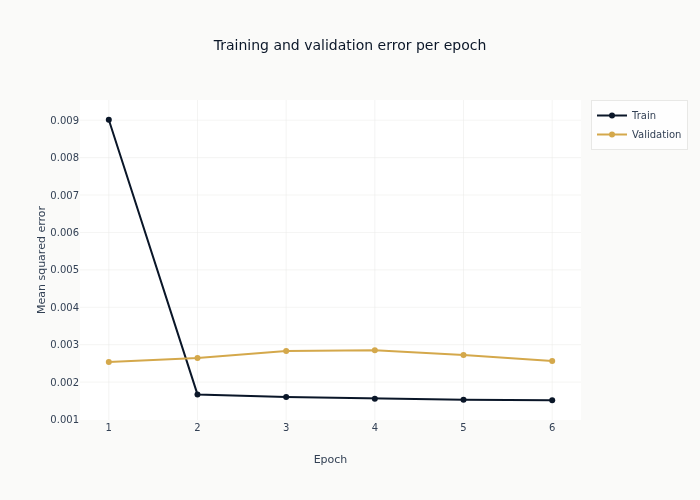

In [14]:
fig = go.Figure()
for label, key, color in [
    ("Train", "train_loss", COLORS["blue"]),
    ("Validation", "val_loss", COLORS["amber"]),
]:
    fig.add_trace(
        go.Scatter(
            x=list(range(1, len(history[key]) + 1)),
            y=history[key],
            mode="lines+markers",
            name=label,
            line={"color": color},
        )
    )
fig.update_layout(
    title="Training and validation error per epoch",
    xaxis_title="Epoch",
    yaxis_title="Mean squared error",
)
show_plotly_with_alt(
    fig,
    "A line chart of mean squared error against epoch, with one line for the training "
    "set and one for the validation set. Training stops when the validation line has "
    "gone the required number of epochs without a new minimum.",
)

## Evaluate on Test Set

In [15]:
model.eval()
with torch.no_grad():
    y_pred_batches = []
    for i in range(0, len(X_test), INFER_BATCH_SIZE):
        X_test_t = torch.FloatTensor(X_test[i : i + INFER_BATCH_SIZE]).to(DEVICE)
        y_pred_batches.append(model(X_test_t).cpu().numpy())
    y_pred = np.concatenate(y_pred_batches)

test_mse = np.mean((y_pred - y_test) ** 2)
mamba_ic = cross_sectional_ic_mean(y_test, y_pred, test_dates, test_symbols)
test_ic = mamba_ic["ic"]

print("\nMamba Test Results:")
print(f"  MSE: {test_mse:.6f}")
print(f"  Spearman IC: {test_ic:.4f}", end="")
print(f"  (defined on {mamba_ic['n_defined']} of {mamba_ic['n_total']} test dates)")


Mamba Test Results:
  MSE: 0.002363
  Spearman IC: -0.0877  (defined on 159 of 159 test dates)


## Ridge Baseline Comparison

Flattening the window into one vector and fitting a penalised linear map gives the
baseline the selective scan has to beat.

The flattened design is `LOOKBACK` x `len(FEATURE_COLS)` columns of overlapping
trailing returns, which are strongly collinear: on this capped sample the Gram
matrix has a condition number around $8 \times 10^6$. scikit-learn's default solver
forms and factorises that matrix and warns that it is ill-conditioned, so `svd` is
requested instead. It computes the same ridge estimator without forming the normal
equations - the two agree to four significant figures on test MSE - and the warning
has no cause rather than being filtered away.

Note also that `alpha` is fixed at 1, not tuned. That keeps the baseline identical
across this section's notebooks, and it means the bars below compare an untuned
linear map with an under-trained network. Neither is at its best.

In [16]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

ridge = Ridge(alpha=1.0, solver="svd")
ridge.fit(X_train_scaled, y_train)
y_ridge_pred = ridge.predict(X_test_scaled)

ridge_mse = np.mean((y_ridge_pred - y_test) ** 2)
ridge_ic_result = cross_sectional_ic_mean(y_test, y_ridge_pred, test_dates, test_symbols)
ridge_ic = ridge_ic_result["ic"]
zero_mse = float(np.mean(y_test**2))

print("\nRidge Baseline Results:")
print(f"  MSE: {ridge_mse:.6f}")
print(f"  Spearman IC: {ridge_ic:.4f}", end="")
print(f"  (defined on {ridge_ic_result['n_defined']} of {ridge_ic_result['n_total']} test dates)")


Ridge Baseline Results:
  MSE: 0.002333
  Spearman IC: 0.0818  (defined on 159 of 159 test dates)


## The selective SSM against the linear baseline

Two questions, two panels. The left asks whether the model ordered the funds usefully
on each date; the right asks whether its predicted return levels were closer than
predicting zero. A model can do better on one and worse on the other, and both are
reported because acting on a forecast uses the ordering while fitting one minimises
the squared error.

The ridge regression sees the same window flattened into one vector and fits a
penalised linear map straight to the label - no state, no selection, no notion that
the columns are ordered in time. Whatever the recurrence is worth has to appear as a
difference from that, within the budget the next paragraph describes.

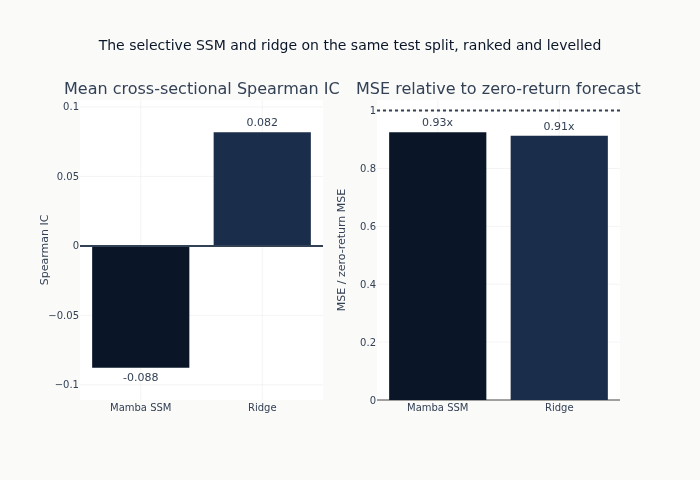

In [17]:
model_names = ["Mamba SSM", "Ridge"]
ic_values = [test_ic, ridge_ic]
mse_ratios = [test_mse / zero_mse, ridge_mse / zero_mse]
bar_palette = {"Mamba SSM": COLORS["blue"], "Ridge": COLORS["slate"]}

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Mean cross-sectional Spearman IC", "MSE relative to zero-return forecast"),
)
for model_name, ic_value, mse_ratio in zip(model_names, ic_values, mse_ratios, strict=True):
    fig.add_trace(
        go.Bar(
            x=[model_name],
            y=[ic_value],
            name=model_name,
            marker_color=bar_palette[model_name],
            text=[f"{ic_value:.3f}"],
            textposition="outside",
            showlegend=False,
        ),
        row=1,
        col=1,
    )
    fig.add_trace(
        go.Bar(
            x=[model_name],
            y=[mse_ratio],
            name=model_name,
            marker_color=bar_palette[model_name],
            text=[f"{mse_ratio:.2f}x"],
            textposition="outside",
            showlegend=False,
        ),
        row=1,
        col=2,
    )


fig.add_hline(y=0, line_color=COLORS["neutral"], row=1, col=1)
fig.add_hline(y=1, line_dash="dot", line_color=COLORS["neutral"], row=1, col=2)
fig.update_layout(
    title="The selective SSM and ridge on the same test split, ranked and levelled",
    height=480,
)
fig.update_yaxes(title_text="Spearman IC", row=1, col=1)
fig.update_yaxes(title_text="MSE / zero-return MSE", row=1, col=2)
show_plotly_with_alt(
    fig,
    "Two bar panels, one bar per model. The left panel gives each model's mean "
    "cross-sectional Spearman IC against a line at zero; the right gives its test MSE "
    "as a multiple of the zero forecast's, against a dotted line at one.",
)

## What the budget lets this comparison say

Both models see the same data: the subsampling above happens before either is fitted,
so the ridge is trained on exactly the sequences the SSM is. What differs is the
fitting. The ridge solution is closed-form and fully converged at its penalty; the
SSM gets at most `EPOCHS` epochs of gradient descent with early stopping, and the
sample is capped at `MAX_TRAIN_SAMPLES` in the first place because the pure-Python
scan runs orders of magnitude slower than the production kernel. Neither model got a
hyperparameter search.

So the figure is a record of what these two models did under this budget, and the
subsampling is the constraint that matters most: both scores are computed over the
most recent complete dates that fit the cap, not over the full test stretch. The
coverage counts printed beside each IC say how many dates each average was taken
over, and they are a small fraction of the dates the other notebooks in this section
score on. Read them before reading the bars.

## Key takeaways

1. **Separate the two claims about cost.** A fixed-size state and bounded work per
   step give $O(T)$ total work; a recurrent network already has that, and attention
   gives it up by making each step look at every other. Linearity is a different
   property, and what it buys is parallelism: because the update is affine and each
   step's coefficients depend only on that step's input, the sweep composes into an
   associative scan instead of waiting for its own previous output.
2. **"Selective" means three quantities move with the input.** $B_t$, $C_t$ and
   $\Delta_t$ all come out of `x_proj` applied to the current input, while $A$ is a
   learned diagonal fixed for the whole sequence. A fixed-parameter SSM such as S4
   has all four constant, so its state decays on a schedule set at training time
   rather than one the input can change.
3. **$\Delta_t$ is the forget control.** It enters as $\exp(\Delta_t A)$ with $A$
   negative, so a large step shrinks the previous state hard and a small one
   preserves it. Reading that one line is how you see what the model can be trained
   to forget.
4. **The gate is a second, multiplicative path.** `in_proj` splits into an SSM branch
   and a gate branch, and the SSM output is multiplied by `silu(z)` before the output
   projection - the same shape of interaction an LSTM's gates provide, without a
   recurrence in the gate itself.
5. **The comparison here is bounded by the training budget, not just the
   architecture.** The loop-based scan forces a capped sample and a handful of
   epochs, so the figure says what this model does under this budget. Reading it as
   a general result about selective SSMs for return prediction would be reading past
   what was run.

**Known limitations.** One chronological split of one ETF panel, one label horizon,
one seed, and a sample capped by the pedagogical scan's speed. The comparison is
against one baseline, and a single split cannot rank architectures;
`12_case_study_insights` is where these families are compared across case studies
under walk-forward validation. Deterministic PyTorch algorithms and a fixed cuBLAS
workspace make repeated execution reproduce on the same software and GPU; another
environment will differ in the final decimals.

**Next**: `08_cnn_image_encoding` gives up on the sequence entirely, turning each
window into a picture and handing it to an image classifier.